<a href="https://colab.research.google.com/github/WahyuKhairi06/SpeechProcessing_WahyuKhairi_2311531009/blob/main/Tugas%20Individu%201/2311531009_WahyuKhairi_Script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Speech processing**

In [1]:
!pip install librosa matplotlib numpy soundfile noisereduce

# Libararies


In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
import noisereduce as nr

# 1. LOAD AUDIO LANGSUNG


In [3]:
print("Memuat file audio...")
# Masukkan nama file audio
y, sr = librosa.load("2311531009-WahyuKhairi-Audio.wav", sr=None)

Memuat file audio...


# 2. MEMVISUALISASIKAN WAVEFORM (SEBELUM)


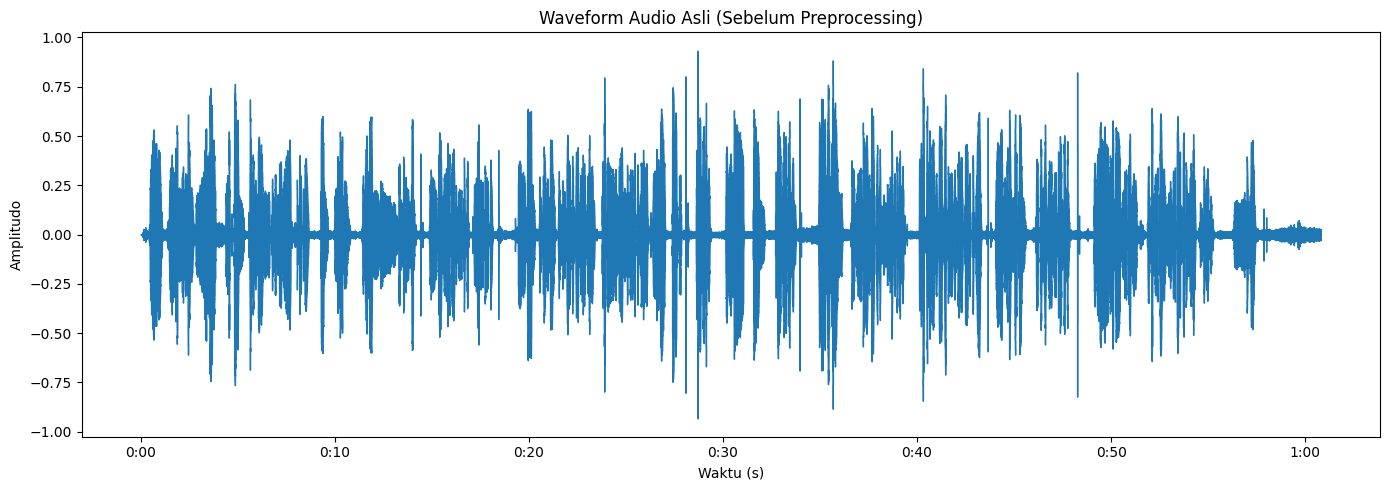

In [4]:
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform Audio Asli (Sebelum Preprocessing)")
plt.xlabel("Waktu (s)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# 3. MEMBUAT SPECTROGRAM (SEBELUM)
Konversi amplitudo ke desibel untuk visualisasi yang lebih baik

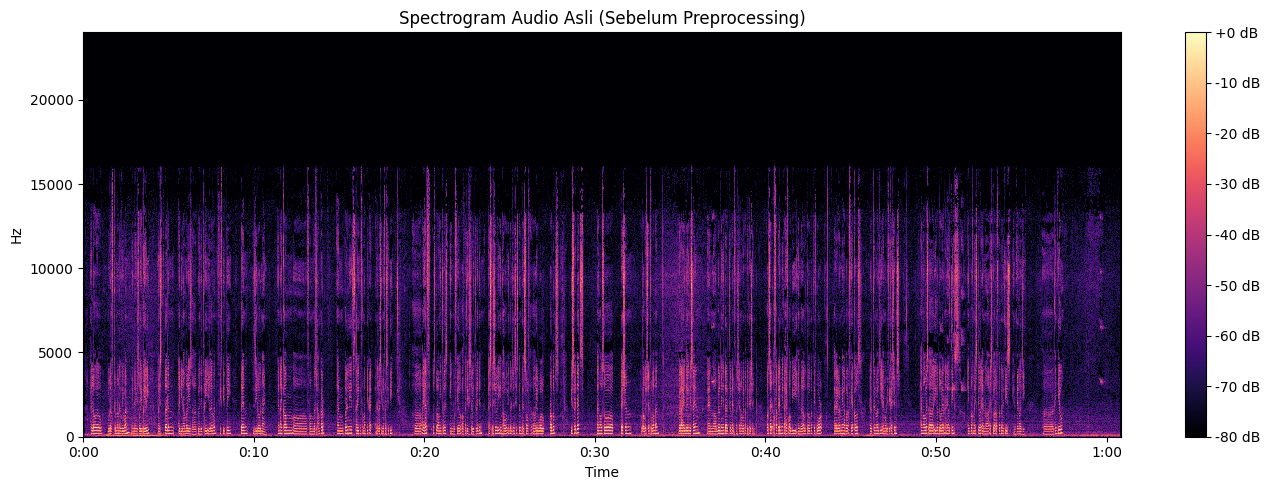

In [5]:
D_asli = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(D_asli, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram Audio Asli (Sebelum Preprocessing)")
plt.tight_layout()
plt.show()

# 4. PREPROCESSING SEDERHANA


In [6]:
print("Melakukan Preprocessing...")

# a. Normalization (Menyesuaikan amplitudo ke rentang -1 hingga 1)
y_norm = y / np.max(np.abs(y))

# b. Silence Removal (Menghapus bagian diam/tidak bersuara)
# top_db=20 adalah threshold; sesuaikan jika terlalu banyak bagian yang terpotong
y_trim, index = librosa.effects.trim(y_norm, top_db=20)

# c. Noise Reduction (Mengurangi noise latar belakang)
y_clean = nr.reduce_noise(y=y_trim, sr=sr)

# Menyimpan audio hasil preprocessing secara langsung
nama_file_preprocessed = "2311531009-wahyu-preprocessing.wav"
sf.write(nama_file_preprocessed, y_clean, sr)
print(f"File preprocessing disimpan: {nama_file_preprocessed}")

# d & e. Framing dan Windowing
# Frame berdurasi 25ms dengan overlap (hop) 10ms
frame_length = int(0.025 * sr)
hop_length = int(0.010 * sr)

# Melakukan Framing
frames = librosa.util.frame(y_clean, frame_length=frame_length, hop_length=hop_length)

# Melakukan Windowing (menggunakan Hamming window)
window = np.hamming(frame_length)
frames_windowed = frames * window[:, np.newaxis]

# Menyimpan 5 file hasil windowing pertama agar disk tidak penuh
jumlah_frame_disimpan = 5
for i in range(min(jumlah_frame_disimpan, frames_windowed.shape[1])):
    nama_file_frame = f"2311531009-wahyu-windowing-{i+1}.wav"
    sf.write(nama_file_frame, frames_windowed[:, i], sr)

print(f"Berhasil menyimpan {min(jumlah_frame_disimpan, frames_windowed.shape[1])} file frame windowing.")

Melakukan Preprocessing...
File preprocessing disimpan: 2311531009-wahyu-preprocessing.wav
Berhasil menyimpan 5 file frame windowing.


# 5. MEMBANDINGKAN HASIL ANALISIS

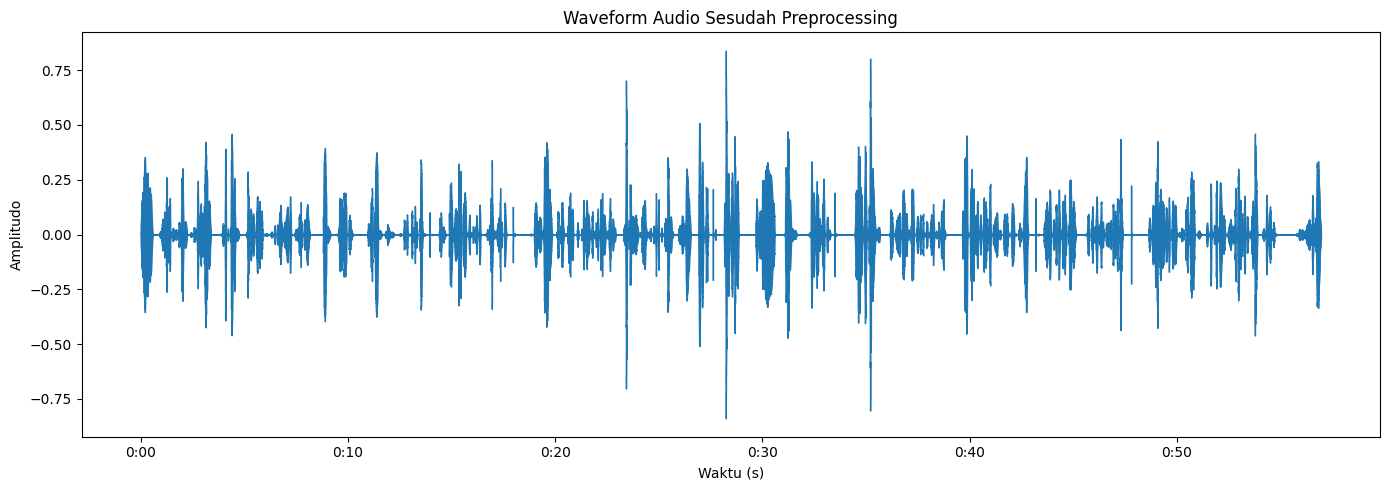

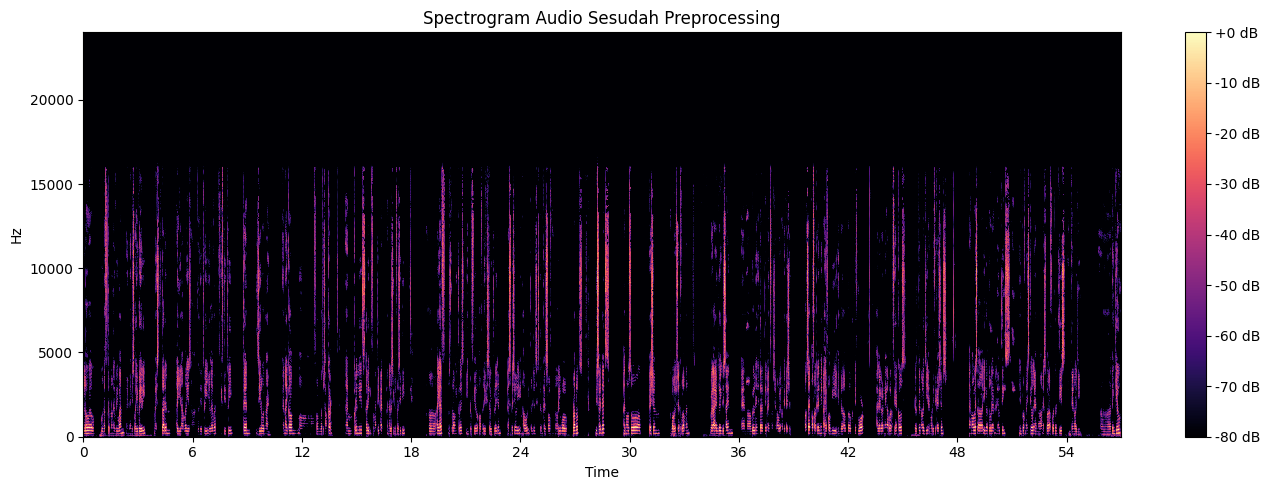

Proses selesai! 


In [7]:
# Waveform Sesudah Preprocessing
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y_clean, sr=sr)
plt.title("Waveform Audio Sesudah Preprocessing")
plt.xlabel("Waktu (s)")
plt.ylabel("Amplitudo")
plt.tight_layout()
plt.show()

# Spectrogram Sesudah Preprocessing
D_clean = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)

plt.figure(figsize=(14, 5))
librosa.display.specshow(D_clean, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram Audio Sesudah Preprocessing")
plt.tight_layout()
plt.show()

print("Proses selesai! ")